In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("heart_disease_dataset.csv")

In [3]:
df.head()

,Age,Gender,Cholesterol,Blood Pressure,Heart Rate,Smoking,Alcohol Intake,Exercise Hours,Family History,Diabetes,Obesity,Stress Level,Blood Sugar,Exercise Induced Angina,Chest Pain Type,Heart Disease
0,75,Female,228,119,66,Current,Heavy,1,No,No,Yes,8,119,Yes,Atypical Angina,1
1,48,Male,204,165,62,Current,NaN,5,No,No,No,9,70,Yes,Typical Angina,0
2,53,Male,234,91,67,Never,Heavy,3,Yes,No,Yes,5,196,Yes,Atypical Angina,1
3,69,Female,192,90,72,Current,NaN,4,No,Yes,No,7,107,Yes,Non-anginal Pain,0
4,62,Female,172,163,93,Never,NaN,6,No,Yes,No,2,183,Yes,Asymptomatic,0


In [4]:
df.shape

(1000, 16)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   Age                      1000 non-null   int64
 1   Gender                   1000 non-null   str  
 2   Cholesterol              1000 non-null   int64
 3   Blood Pressure           1000 non-null   int64
 4   Heart Rate               1000 non-null   int64
 5   Smoking                  1000 non-null   str  
 6   Alcohol Intake           660 non-null    str  
 7   Exercise Hours           1000 non-null   int64
 8   Family History           1000 non-null   str  
 9   Diabetes                 1000 non-null   str  
 10  Obesity                  1000 non-null   str  
 11  Stress Level             1000 non-null   int64
 12  Blood Sugar              1000 non-null   int64
 13  Exercise Induced Angina  1000 non-null   str  
 14  Chest Pain Type          1000 non-null   str  
 15  Heart Disease   

In [6]:
df.describe()

,Age,Cholesterol,Blood Pressure,Heart Rate,Exercise Hours,Stress Level,Blood Sugar,Heart Disease
count,1000.000000,1000.000000,1000.0000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,52.293000,249.939000,135.2810,79.204000,4.529000,5.646000,134.941000,0.392000
std,15.727126,57.914673,26.3883,11.486092,2.934241,2.831024,36.699624,0.488441
min,25.000000,150.000000,90.0000,60.000000,0.000000,1.000000,70.000000,0.000000
25%,39.000000,200.000000,112.7500,70.000000,2.000000,3.000000,104.000000,0.000000
50%,52.000000,248.000000,136.0000,79.000000,4.500000,6.000000,135.000000,0.000000
75%,66.000000,299.000000,159.0000,89.000000,7.000000,8.000000,167.000000,1.000000
max,79.000000,349.000000,179.0000,99.000000,9.000000,10.000000,199.000000,1.000000


In [7]:
df.isnull().sum()

Age                          0
Gender                       0
Cholesterol                  0
Blood Pressure               0
Heart Rate                   0
Smoking                      0
Alcohol Intake             340
Exercise Hours               0
Family History               0
Diabetes                     0
Obesity                      0
Stress Level                 0
Blood Sugar                  0
Exercise Induced Angina      0
Chest Pain Type              0
Heart Disease                0
dtype: int64

In [8]:
df["Alcohol Intake"].value_counts(dropna=False)

Alcohol Intake
Heavy       346
NaN         340
Moderate    314
Name: count, dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df["Alcohol Intake"] = df["Alcohol Intake"].fillna("Unknown")

In [11]:
df["Alcohol Intake"].value_counts(dropna=False)

Alcohol Intake
Heavy       346
Unknown     340
Moderate    314
Name: count, dtype: int64

In [12]:
for col in df.select_dtypes(include="str").columns:
    print("\n")
    print(df[col].value_counts(dropna=False))



Gender
Female    503
Male      497
Name: count, dtype: int64


Smoking
Never      338
Current    336
Former     326
Name: count, dtype: int64


Alcohol Intake
Heavy       346
Unknown     340
Moderate    314
Name: count, dtype: int64


Family History
No     501
Yes    499
Name: count, dtype: int64


Diabetes
Yes    505
No     495
Name: count, dtype: int64


Obesity
No     501
Yes    499
Name: count, dtype: int64


Exercise Induced Angina
No     528
Yes    472
Name: count, dtype: int64


Chest Pain Type
Non-anginal Pain    256
Typical Angina      250
Asymptomatic        248
Atypical Angina     246
Name: count, dtype: int64


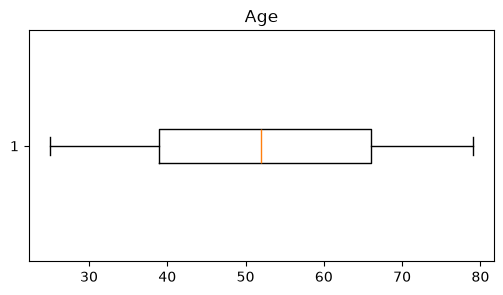

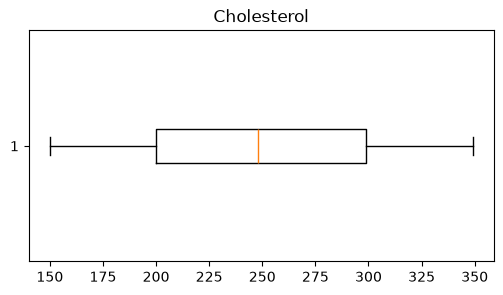

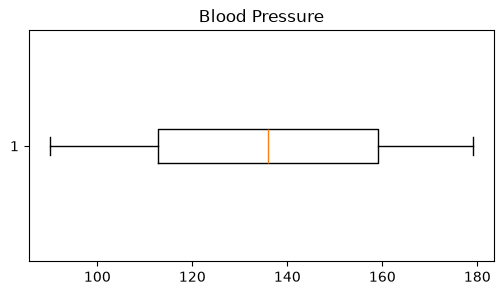

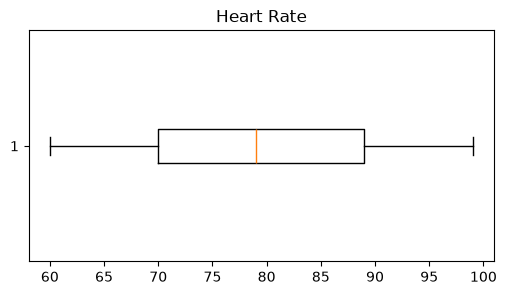

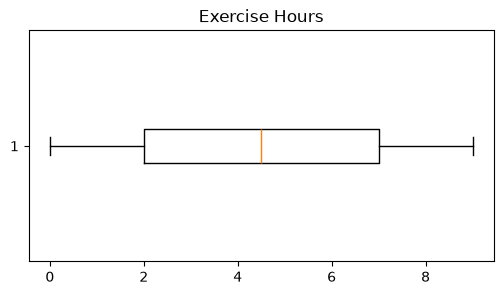

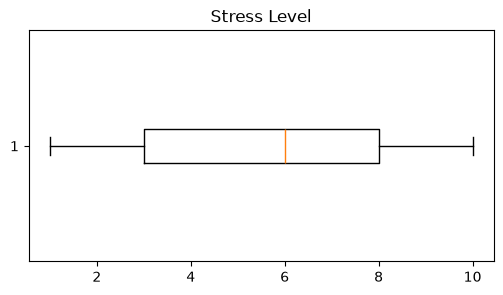

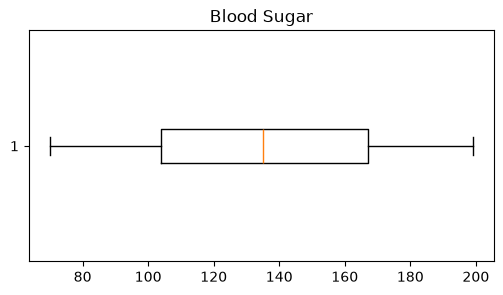

In [13]:
num_cols = df.select_dtypes(include="number").drop(columns="Heart Disease").columns

for col in num_cols:
    plt.figure(figsize=(6,3))
    plt.boxplot(df[col], vert=False)
    plt.title(col)
    plt.show()

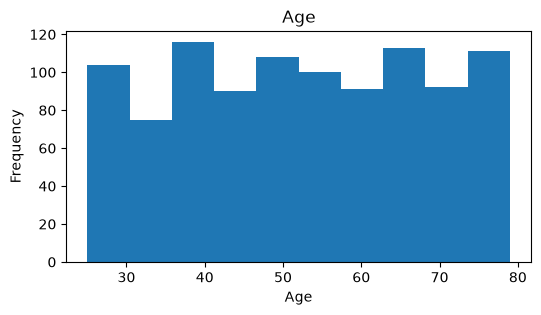

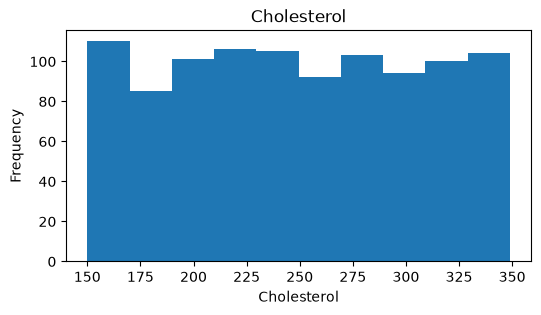

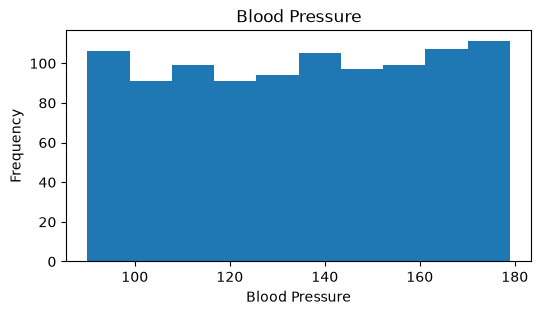

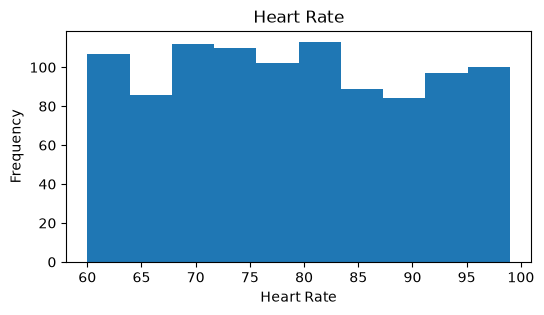

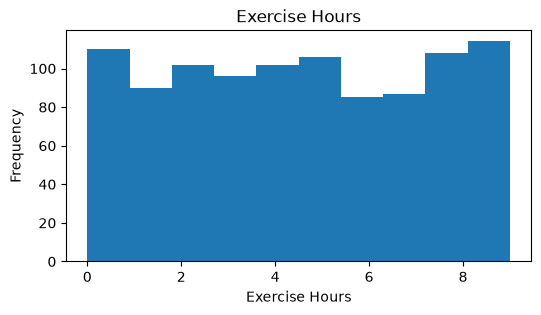

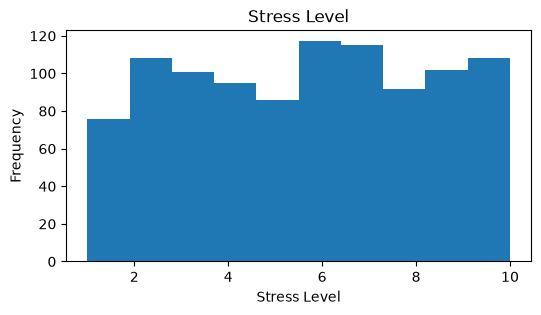

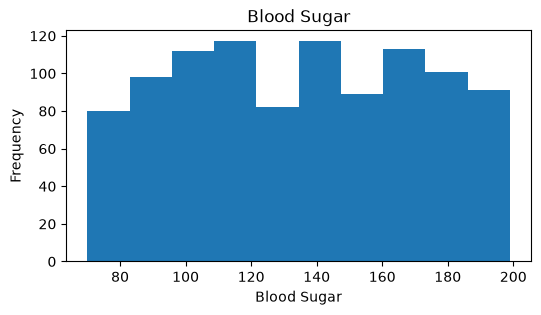

In [14]:
num_cols = df.select_dtypes(include="number").drop(columns="Heart Disease").columns

for col in num_cols:
    plt.figure(figsize=(6,3))
    plt.hist(df[col], bins=10)
    plt.title(col)
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

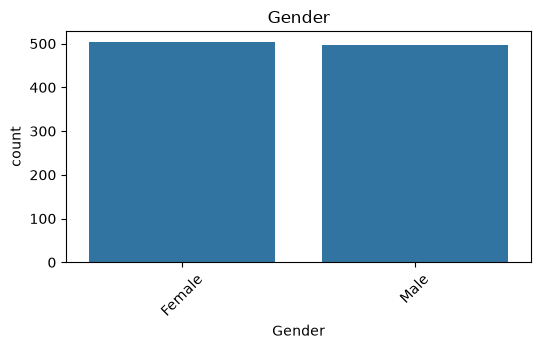

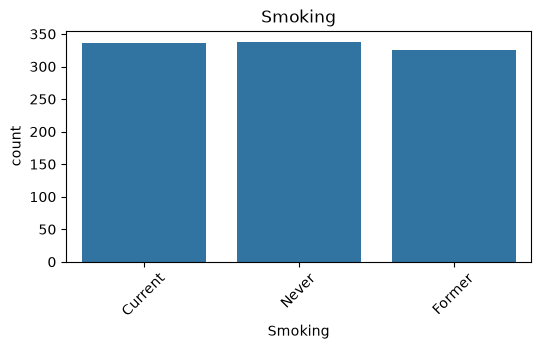

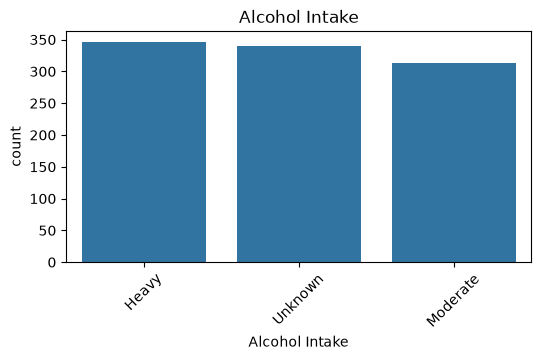

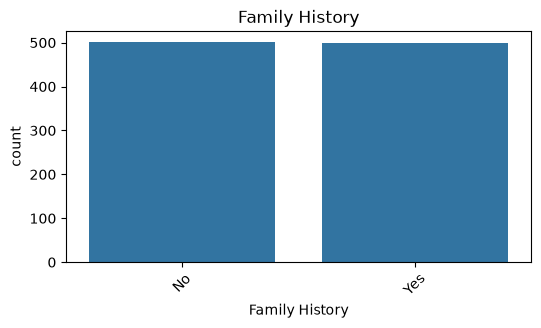

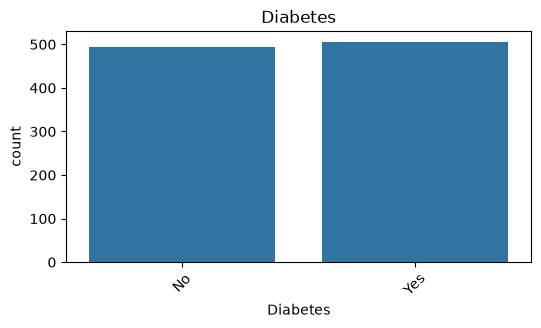

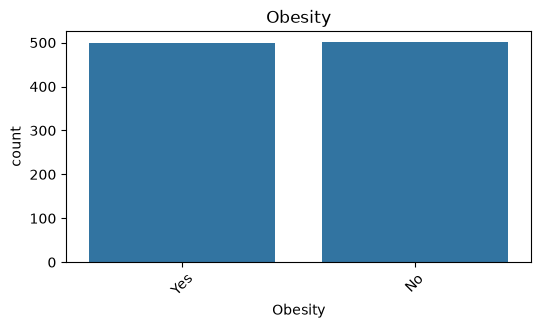

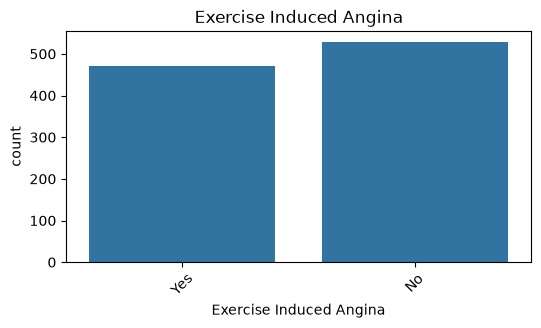

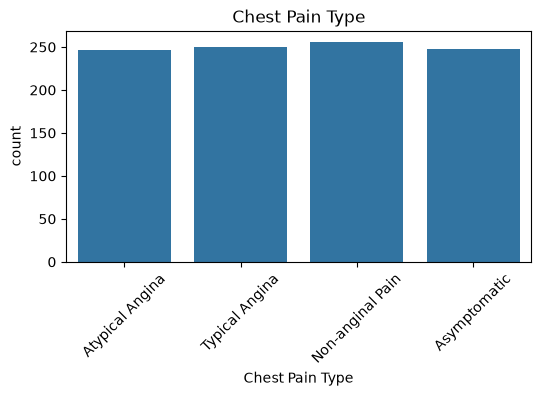

In [15]:
cat_cols = df.select_dtypes(include="str").columns

for col in cat_cols:
    plt.figure(figsize=(6,3))
    sns.countplot(x=col, data=df)
    plt.title(col)
    plt.xticks(rotation=45)
    plt.show()

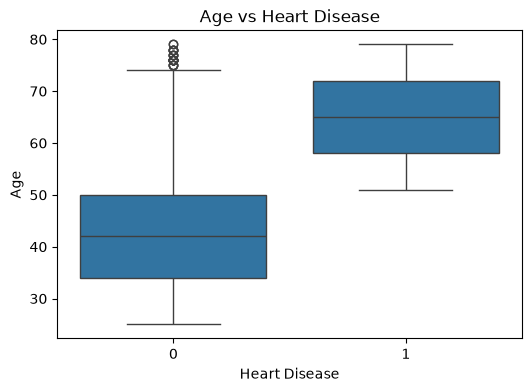

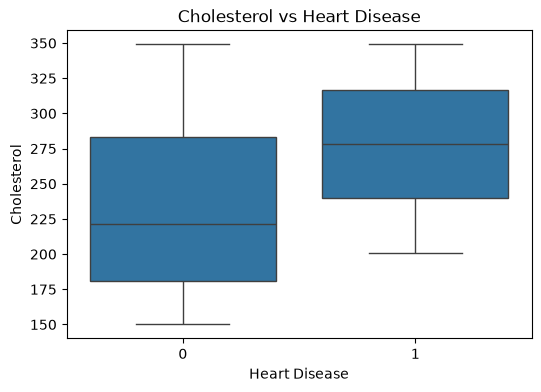

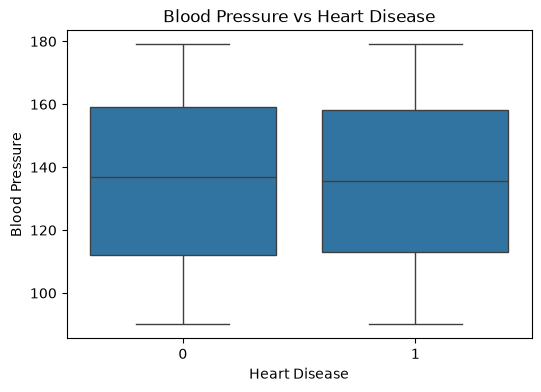

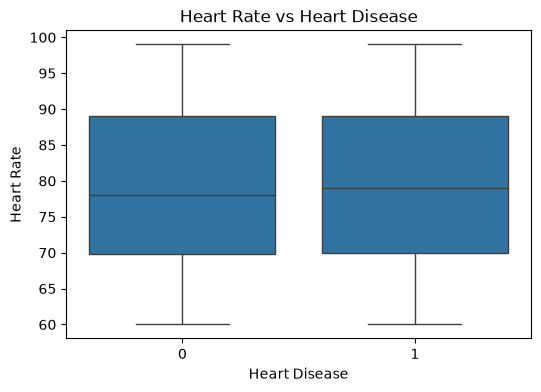

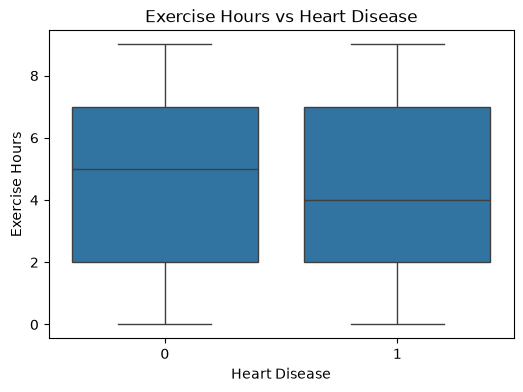

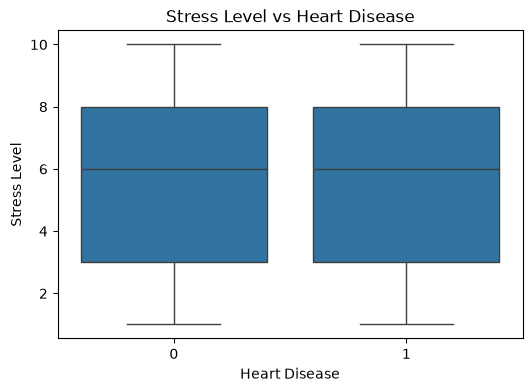

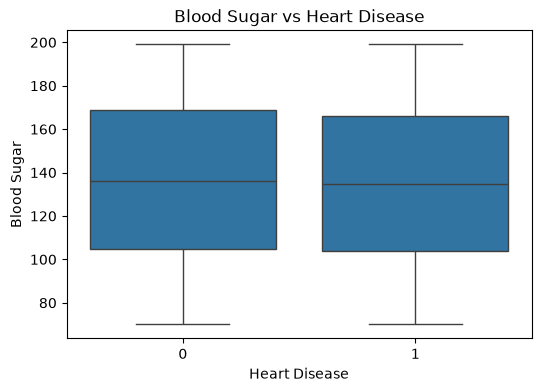

In [16]:
num_cols = df.select_dtypes(include="number").drop(columns="Heart Disease").columns

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x="Heart Disease", y=col, data=df)
    plt.title(f"{col} vs Heart Disease")
    plt.show()

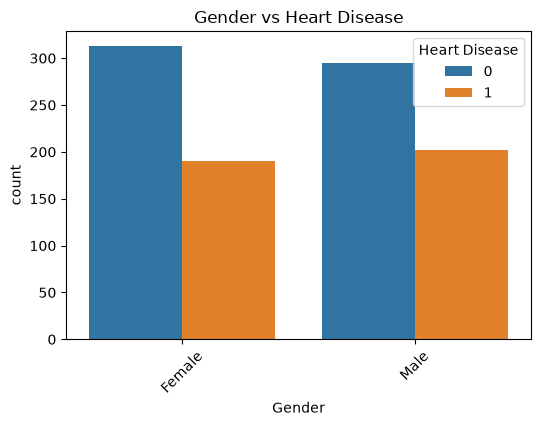

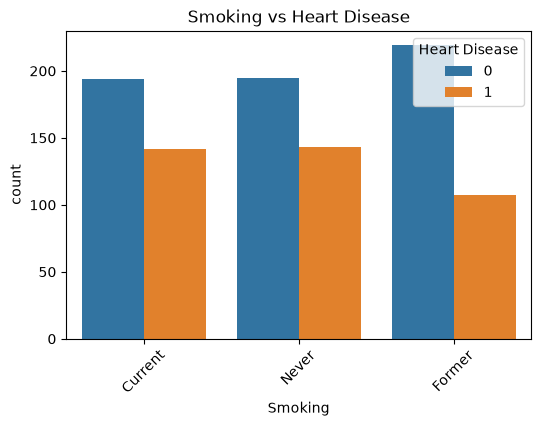

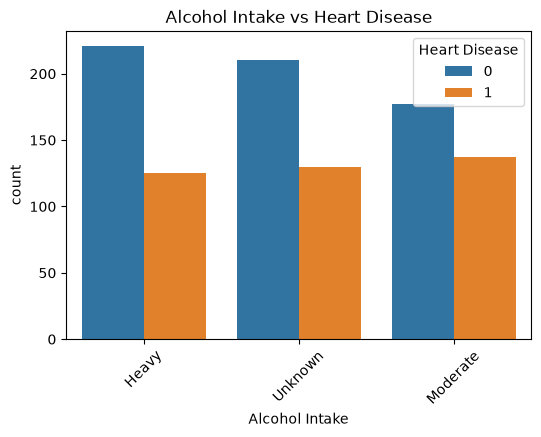

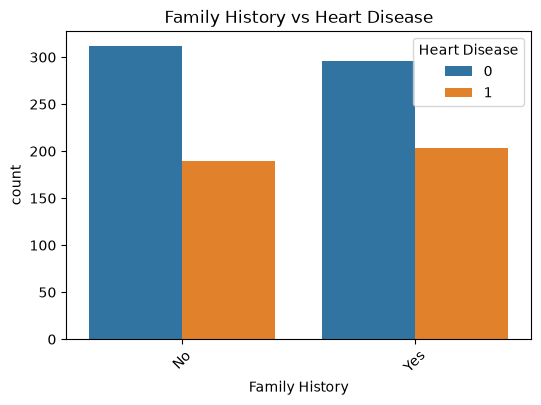

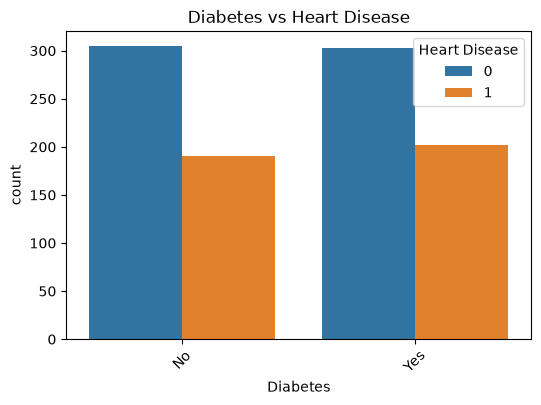

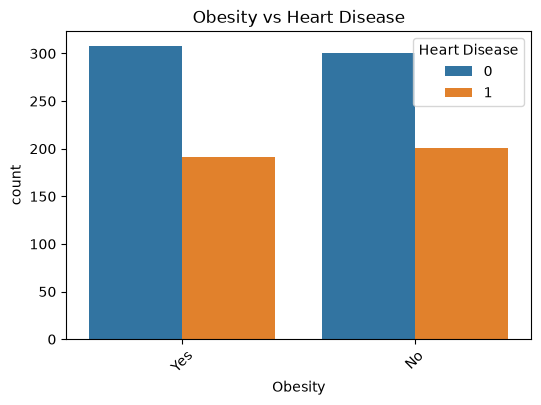

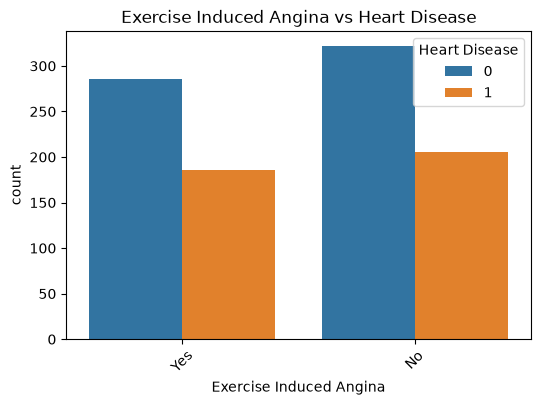

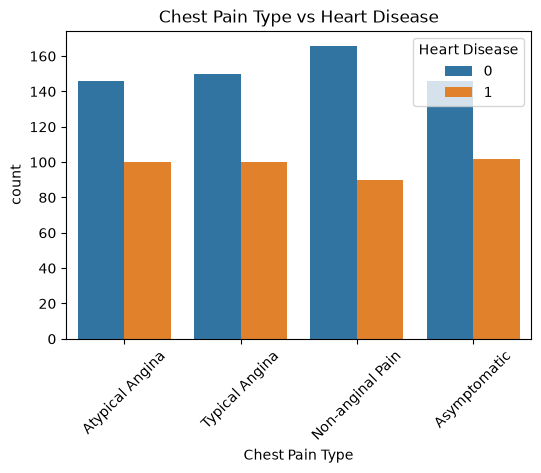

In [17]:
cat_cols = df.select_dtypes(include="object").columns

for col in cat_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(x=col, hue="Heart Disease", data=df)
    plt.title(f"{col} vs Heart Disease")
    plt.xticks(rotation=45)
    plt.show()

In [18]:
corr = df.select_dtypes(include="number").corr()

corr

,Age,Cholesterol,Blood Pressure,Heart Rate,Exercise Hours,Stress Level,Blood Sugar,Heart Disease
Age,1.000000,-0.010673,0.002093,0.029027,-0.021366,-0.045555,-0.041676,0.646871
Cholesterol,-0.010673,1.000000,0.021841,-0.008527,0.016124,0.090458,0.002484,0.365041
Blood Pressure,0.002093,0.021841,1.000000,-0.001675,0.011924,0.002257,-0.053516,0.006900
Heart Rate,0.029027,-0.008527,-0.001675,1.000000,-0.013541,-0.040504,0.010240,0.013209
Exercise Hours,-0.021366,0.016124,0.011924,-0.013541,1.000000,-0.006957,-0.034503,-0.014226
Stress Level,-0.045555,0.090458,0.002257,-0.040504,-0.006957,1.000000,-0.007918,0.007071
Blood Sugar,-0.041676,0.002484,-0.053516,0.010240,-0.034503,-0.007918,1.000000,-0.013004
Heart Disease,0.646871,0.365041,0.006900,0.013209,-0.014226,0.007071,-0.013004,1.000000


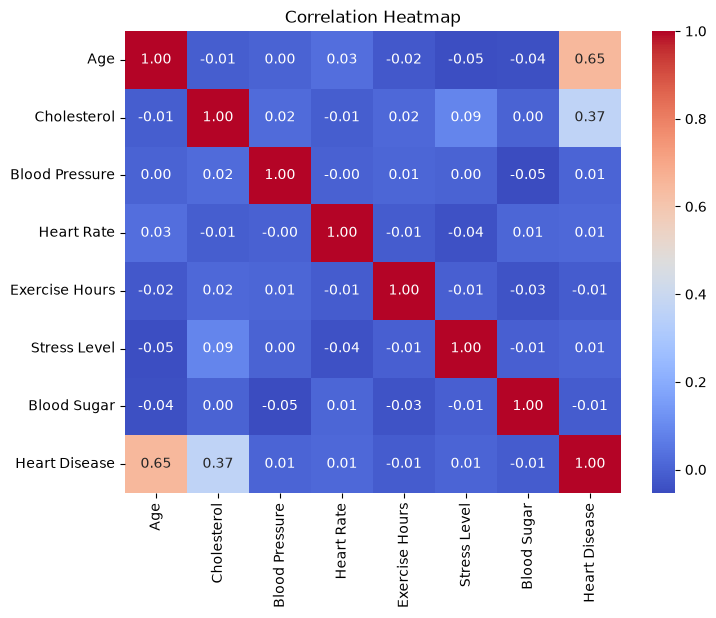

In [19]:
plt.figure(figsize=(8,6))
sns.heatmap(df.select_dtypes(include="number").corr(),
            annot=True,
            cmap="coolwarm",
            fmt=".2f")

plt.title("Correlation Heatmap")
plt.show()

In [20]:
from sklearn.preprocessing import LabelEncoder

label_encoders = {}

label_cols = [
    "Gender",
    "Family History",
    "Diabetes",
    "Obesity",
    "Exercise Induced Angina"
]

for col in label_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = dict(zip(le.classes_, le.transform(le.classes_)))

for col, mapping in label_encoders.items():
    print(f"{col}: {mapping}")

Gender: {'Female': np.int64(0), 'Male': np.int64(1)}
Family History: {'No': np.int64(0), 'Yes': np.int64(1)}
Diabetes: {'No': np.int64(0), 'Yes': np.int64(1)}
Obesity: {'No': np.int64(0), 'Yes': np.int64(1)}
Exercise Induced Angina: {'No': np.int64(0), 'Yes': np.int64(1)}


In [21]:
from sklearn.preprocessing import OneHotEncoder

one_hot_cols = ["Smoking", "Alcohol Intake", "Chest Pain Type"]

encoder = OneHotEncoder(sparse_output=False)

encoded_data = encoder.fit_transform(df[one_hot_cols])

print(encoded_data)
encoded_df = pd.DataFrame(
    encoded_data,
    columns=encoder.get_feature_names_out(one_hot_cols),
    index=df.index
)

df = pd.concat(
    [df.drop(columns=one_hot_cols), encoded_df],
    axis=1
)

print(df.head())

[[1. 0. 0. ... 1. 0. 0.]
 [1. 0. 0. ... 0. 0. 1.]
 [0. 0. 1. ... 1. 0. 0.]
 ...
 [0. 0. 1. ... 0. 0. 0.]
 [0. 1. 0. ... 1. 0. 0.]
 [1. 0. 0. ... 0. 0. 0.]]
   Age  Gender  Cholesterol  Blood Pressure  Heart Rate  Exercise Hours  \
0   75       0          228             119          66               1   
1   48       1          204             165          62               5   
2   53       1          234              91          67               3   
3   69       0          192              90          72               4   
4   62       0          172             163          93               6   

   Family History  Diabetes  Obesity  Stress Level  ...  Smoking_Current  \
0               0         0        1             8  ...              1.0   
1               0         0        0             9  ...              1.0   
2               1         0        1             5  ...              0.0   
3               0         1        0             7  ...              1.0   
4            

In [22]:
df.head()

,Age,Gender,Cholesterol,Blood Pressure,Heart Rate,Exercise Hours,Family History,Diabetes,Obesity,Stress Level,...,Smoking_Current,Smoking_Former,Smoking_Never,Alcohol Intake_Heavy,Alcohol Intake_Moderate,Alcohol Intake_Unknown,Chest Pain Type_Asymptomatic,Chest Pain Type_Atypical Angina,Chest Pain Type_Non-anginal Pain,Chest Pain Type_Typical Angina
0,75,0,228,119,66,1,0,0,1,8,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
1,48,1,204,165,62,5,0,0,0,9,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
2,53,1,234,91,67,3,1,0,1,5,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
3,69,0,192,90,72,4,0,1,0,7,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
4,62,0,172,163,93,6,0,1,0,2,...,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0


In [23]:
X = df.drop("Heart Disease", axis=1)
y = df["Heart Disease"]

In [24]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1000, 22)
y shape: (1000,)


In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (800, 22)
X_test: (200, 22)
y_train: (800,)
y_test: (200,)


In [26]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)

X_train_scaled shape: (800, 22)
X_test_scaled shape: (200, 22)


In [27]:
df.head()

,Age,Gender,Cholesterol,Blood Pressure,Heart Rate,Exercise Hours,Family History,Diabetes,Obesity,Stress Level,...,Smoking_Current,Smoking_Former,Smoking_Never,Alcohol Intake_Heavy,Alcohol Intake_Moderate,Alcohol Intake_Unknown,Chest Pain Type_Asymptomatic,Chest Pain Type_Atypical Angina,Chest Pain Type_Non-anginal Pain,Chest Pain Type_Typical Angina
0,75,0,228,119,66,1,0,0,1,8,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
1,48,1,204,165,62,5,0,0,0,9,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
2,53,1,234,91,67,3,1,0,1,5,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
3,69,0,192,90,72,4,0,1,0,7,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
4,62,0,172,163,93,6,0,1,0,2,...,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0


In [28]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression()
log_model.fit(X_train_scaled, y_train)
y_pred = log_model.predict(X_test_scaled)

In [29]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.87


In [30]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[106  12]
 [ 14  68]]


In [31]:
from sklearn.metrics import precision_score

precision = precision_score(y_test, y_pred)

print("Precision:", precision)

Precision: 0.85


In [32]:
from sklearn.metrics import recall_score

recall = recall_score(y_test, y_pred)

print("Recall:", recall)

Recall: 0.8292682926829268


In [33]:
from sklearn.metrics import f1_score

f1 = f1_score(y_test, y_pred)

print("F1 Score:", f1)

F1 Score: 0.8395061728395061


In [34]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.90      0.89       118
           1       0.85      0.83      0.84        82

    accuracy                           0.87       200
   macro avg       0.87      0.86      0.87       200
weighted avg       0.87      0.87      0.87       200



In [35]:
from sklearn.tree import DecisionTreeClassifier
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_scaled, y_train)
y_pred_dt = dt_model.predict(X_test_scaled)

In [36]:
from sklearn.metrics import accuracy_score

accuracy_dt = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy:", accuracy_dt)

Decision Tree Accuracy: 1.0


In [37]:
from sklearn.metrics import confusion_matrix

cm_dt = confusion_matrix(y_test, y_pred_dt)

print(cm_dt)

[[118   0]
 [  0  82]]


In [38]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision_dt = precision_score(y_test, y_pred_dt)
recall_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)

print("Precision:", precision_dt)
print("Recall:", recall_dt)
print("F1 Score:", f1_dt)

Precision: 1.0
Recall: 1.0
F1 Score: 1.0


In [39]:
y_train_pred = dt_model.predict(X_train_scaled)

train_accuracy = accuracy_score(y_train, y_train_pred)

print("Training Accuracy:", train_accuracy)
print("Testing Accuracy:", accuracy_dt)

Training Accuracy: 1.0
Testing Accuracy: 1.0


In [40]:
print("Tree depth:", dt_model.get_depth())
print("Number of leaves:", dt_model.get_n_leaves()) 


Tree depth: 2
Number of leaves: 3


In [41]:
print(dt_model.feature_importances_)

[0.57240039 0.         0.42759961 0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.        ]


In [42]:
for feature, importance in zip(X_train.columns, dt_model.feature_importances_):
    print(feature, importance)

Age 0.5724003887269195
Gender 0.0
Cholesterol 0.42759961127308055
Blood Pressure 0.0
Heart Rate 0.0
Exercise Hours 0.0
Family History 0.0
Diabetes 0.0
Obesity 0.0
Stress Level 0.0
Blood Sugar 0.0
Exercise Induced Angina 0.0
Smoking_Current 0.0
Smoking_Former 0.0
Smoking_Never 0.0
Alcohol Intake_Heavy 0.0
Alcohol Intake_Moderate 0.0
Alcohol Intake_Unknown 0.0
Chest Pain Type_Asymptomatic 0.0
Chest Pain Type_Atypical Angina 0.0
Chest Pain Type_Non-anginal Pain 0.0
Chest Pain Type_Typical Angina 0.0


In [43]:
print(dt_model.tree_.threshold)

[-0.11558658 -2.         -0.85547066 -2.         -2.        ]


In [44]:
print(dt_model.tree_.feature)

[ 0 -2  2 -2 -2]


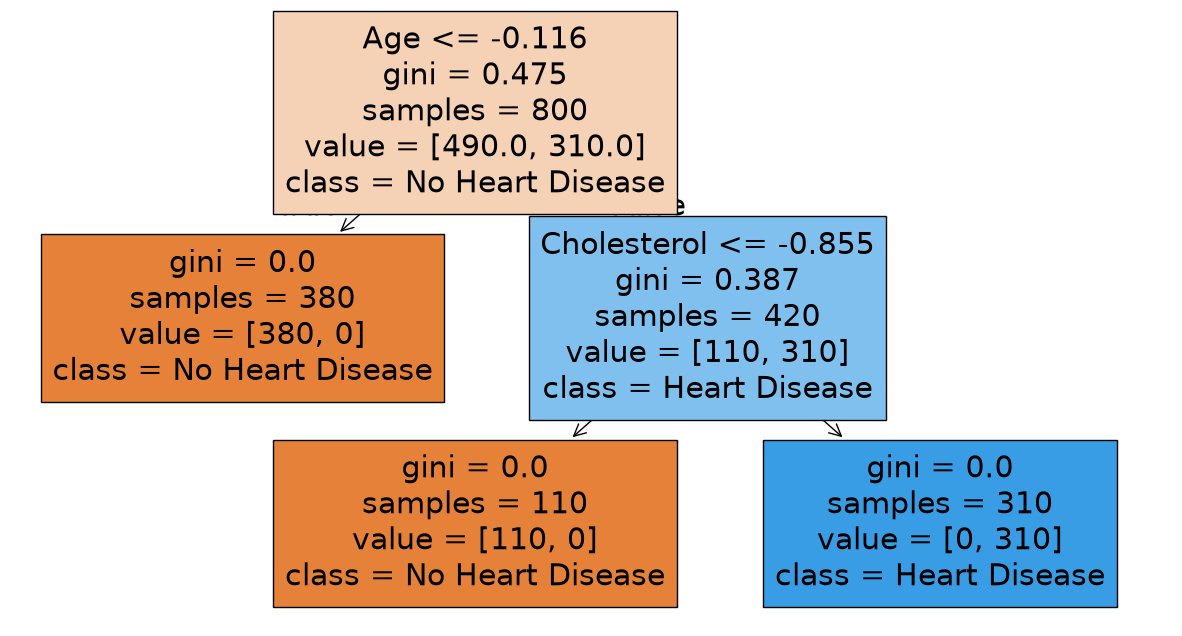

In [45]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 8))

plot_tree(
    dt_model,
    feature_names=X_train.columns,
    class_names=["No Heart Disease", "Heart Disease"],
    filled=True
)

plt.show()

In [46]:
from sklearn.ensemble import RandomForestClassifier
RF = RandomForestClassifier(n_estimators=100, random_state=42, oob_score=True)
RF.fit(X_train, y_train)
y_pred = RF.predict(X_test)

In [47]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 1.0


In [48]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[118   0]
 [  0  82]]


In [49]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       118
           1       1.00      1.00      1.00        82

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



In [50]:
print(X.columns)

Index(['Age', 'Gender', 'Cholesterol', 'Blood Pressure', 'Heart Rate',
       'Exercise Hours', 'Family History', 'Diabetes', 'Obesity',
       'Stress Level', 'Blood Sugar', 'Exercise Induced Angina',
       'Smoking_Current', 'Smoking_Former', 'Smoking_Never',
       'Alcohol Intake_Heavy', 'Alcohol Intake_Moderate',
       'Alcohol Intake_Unknown', 'Chest Pain Type_Asymptomatic',
       'Chest Pain Type_Atypical Angina', 'Chest Pain Type_Non-anginal Pain',
       'Chest Pain Type_Typical Angina'],
      dtype='str')


In [51]:
y_train_pred = RF.predict(X_train)

train_accuracy = accuracy_score(y_train, y_train_pred)

print("Training Accuracy:", train_accuracy)
print("Testing Accuracy:", accuracy)

Training Accuracy: 1.0
Testing Accuracy: 1.0


In [52]:
for feature, importance in zip(X.columns, RF.feature_importances_):
    print(feature, ":", importance)

Age : 0.5034930257802545
Gender : 0.005929749395497322
Cholesterol : 0.2530749976879797
Blood Pressure : 0.035148688792798456
Heart Rate : 0.036211536437695056
Exercise Hours : 0.019259608442667688
Family History : 0.00834148875066548
Diabetes : 0.005835926285587226
Obesity : 0.0064243334420642515
Stress Level : 0.022565930297422765
Blood Sugar : 0.03948157404694947
Exercise Induced Angina : 0.006320897912826012
Smoking_Current : 0.004811103550351714
Smoking_Former : 0.00700184985043511
Smoking_Never : 0.006644468004183654
Alcohol Intake_Heavy : 0.005710166121044961
Alcohol Intake_Moderate : 0.00664996014424595
Alcohol Intake_Unknown : 0.006018754794278101
Chest Pain Type_Asymptomatic : 0.005255856320815732
Chest Pain Type_Atypical Angina : 0.006362456060915938
Chest Pain Type_Non-anginal Pain : 0.005285512181788672
Chest Pain Type_Typical Angina : 0.004172115699532504


In [53]:
print(df.groupby("Heart Disease")["Age"].mean())

Heart Disease
0    44.128289
1    64.956633
Name: Age, dtype: float64


In [54]:
print(df.groupby("Heart Disease")["Cholesterol"].mean())

Heart Disease
0    232.972039
1    276.255102
Name: Cholesterol, dtype: float64


In [55]:
print(df["Heart Disease"].value_counts())

Heart Disease
0    608
1    392
Name: count, dtype: int64


In [56]:
print(RF.estimators_[0].get_depth())

15


In [57]:
print("OOB Score:", RF.oob_score_)

OOB Score: 0.995


In [ ]:
print(df.groupby("Heart Disease")["Blood Pressure"].mean())

Heart Disease
0    135.134868
1    135.507653
Name: Blood Pressure, dtype: float64


In [ ]:
print(df.groupby("Heart Disease")["Age"].agg(["min", "max"]))

               min  max
Heart Disease          
0               25   79
1               51   79


In [ ]:
print(df.groupby("Heart Disease")["Cholesterol"].agg(["min", "max"]))

               min  max
Heart Disease          
0              150  349
1              201  349


In [ ]:
from sklearn.model_selection import cross_val_score
cv_scores = cross_val_score(RF, X_train, y_train, cv=5)
print(cv_scores)

[0.99375 0.9875  1.      1.      1.     ]


In [ ]:
print("Mean CV Score:", cv_scores.mean())

Mean CV Score: 0.9962500000000001


In [68]:
joblib.dump(label_encoders, "label_encoders.pkl")

['label_encoders.pkl']

In [69]:
joblib.dump(encoder, "onehot_encoder.pkl")

['onehot_encoder.pkl']